<a href="https://colab.research.google.com/github/ydv-prince/EDA/blob/main/7_EDA_US_Visa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [194]:
#This EDA has a lot of visulaisation and feature engineering
#It is a great example of preparatrion of target variable case_status

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Steps to read data from a link using pandas:

1.  **Ensure the link is a direct download link for the CSV file.**

    *   **For Google Drive:** If your CSV file is on Google Drive, you need to get a direct download link. Sharing a file or folder usually provides a link to the Google Drive interface, not the raw file. To get a direct link for a Google Drive file:
        1.  Make sure the file is shared with 'Anyone with the link'.
        2.  Copy the shareable link. It usually looks something like `https://drive.google.com/file/d/FILE_ID/view?usp=sharing`.
        3.  Replace `view?usp=sharing` with `export?format=csv&id=FILE_ID` or `uc?export=download&id=FILE_ID`.
            *   **Example:** If your file ID is `1rpxngGYRlGHnikL_lUOSDsWWrpwvWtxJ` (which appears to be a folder ID, not a file ID, from your previous attempt), the direct download link would be `https://drive.google.com/uc?export=download&id=YOUR_FILE_ID`.

2.  **Use `pd.read_csv()` with the direct URL.**

    Once you have the direct URL, you can pass it directly to `pd.read_csv()`.

In [195]:
df = pd.read_csv('us_perm_visas.csv')

In [196]:
df

,add_these_pw_job_title_9089,agent_city,agent_firm_name,agent_state,application_type,case_no,case_number,case_received_date,case_status,class_of_admission,...,ri_pvt_employment_firm_to,ri_us_workers_considered,schd_a_sheepherder,us_economic_sector,wage_offer_from_9089,wage_offer_to_9089,wage_offer_unit_of_pay_9089,wage_offered_from_9089,wage_offered_to_9089,wage_offered_unit_of_pay_9089
0,NaN,NaN,NaN,NaN,PERM,A-07323-97014,NaN,NaN,Certified,J-1,...,NaN,NaN,NaN,IT,75629.0,NaN,yr,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,PERM,A-07332-99439,NaN,NaN,Denied,B-2,...,NaN,NaN,NaN,Other Economic Sector,37024.0,NaN,yr,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,PERM,A-07333-99643,NaN,NaN,Certified,H-1B,...,NaN,NaN,NaN,Aerospace,47923.0,NaN,yr,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,PERM,A-07339-01930,NaN,NaN,Certified,B-2,...,NaN,NaN,NaN,Other Economic Sector,10.97,NaN,hr,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,PERM,A-07345-03565,NaN,NaN,Certified,L-1,...,NaN,NaN,NaN,Advanced Mfg,100000.0,NaN,yr,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374357,NaN,Buena Park,Law Offices of Yohan Lee,CA,NaN,NaN,A-16363-85407,2016-12-29,Withdrawn,NaN,...,NaN,NaN,N,NaN,"28,330.00",NaN,Year,NaN,NaN,NaN
374358,NaN,Seattle,MacDonald Hoague & Bayless,WA,NaN,NaN,A-16271-56745,2016-12-30,Withdrawn,L-1,...,NaN,Y,N,NaN,"122,000.00","142,000.00",Year,NaN,NaN,NaN
374359,NaN,Schaumburg,International Legal and Business Services Grou...,IL,NaN,NaN,A-16354-82345,2016-12-30,Withdrawn,H-1B,...,NaN,NaN,N,NaN,"79,082.00","79,082.00",Year,NaN,NaN,NaN
374360,NaN,LOS ANGELES,LAW OFFICES OF JAMES S HONG,CA,NaN,NaN,A-16357-84250,2016-12-30,Withdrawn,B-2,...,NaN,NaN,N,NaN,"37,981.00",NaN,Year,NaN,NaN,NaN


In [197]:
df.shape

(374362, 154)

In [198]:
df.sample(1)

,add_these_pw_job_title_9089,agent_city,agent_firm_name,agent_state,application_type,case_no,case_number,case_received_date,case_status,class_of_admission,...,ri_pvt_employment_firm_to,ri_us_workers_considered,schd_a_sheepherder,us_economic_sector,wage_offer_from_9089,wage_offer_to_9089,wage_offer_unit_of_pay_9089,wage_offered_from_9089,wage_offered_to_9089,wage_offered_unit_of_pay_9089
116101,NaN,NaN,NaN,NaN,ONLINE,A-13225-87860,NaN,NaN,Certified,H-1B,...,NaN,NaN,NaN,IT,NaN,NaN,NaN,87402.0,NaN,Year


In [199]:
df.tail(5)

,add_these_pw_job_title_9089,agent_city,agent_firm_name,agent_state,application_type,case_no,case_number,case_received_date,case_status,class_of_admission,...,ri_pvt_employment_firm_to,ri_us_workers_considered,schd_a_sheepherder,us_economic_sector,wage_offer_from_9089,wage_offer_to_9089,wage_offer_unit_of_pay_9089,wage_offered_from_9089,wage_offered_to_9089,wage_offered_unit_of_pay_9089
374357,NaN,Buena Park,Law Offices of Yohan Lee,CA,NaN,NaN,A-16363-85407,2016-12-29,Withdrawn,NaN,...,NaN,NaN,N,NaN,"28,330.00",NaN,Year,NaN,NaN,NaN
374358,NaN,Seattle,MacDonald Hoague & Bayless,WA,NaN,NaN,A-16271-56745,2016-12-30,Withdrawn,L-1,...,NaN,Y,N,NaN,"122,000.00","142,000.00",Year,NaN,NaN,NaN
374359,NaN,Schaumburg,International Legal and Business Services Grou...,IL,NaN,NaN,A-16354-82345,2016-12-30,Withdrawn,H-1B,...,NaN,NaN,N,NaN,"79,082.00","79,082.00",Year,NaN,NaN,NaN
374360,NaN,LOS ANGELES,LAW OFFICES OF JAMES S HONG,CA,NaN,NaN,A-16357-84250,2016-12-30,Withdrawn,B-2,...,NaN,NaN,N,NaN,"37,981.00",NaN,Year,NaN,NaN,NaN
374361,NaN,Phoenix,"Fragomen, Del Rey, Bernsen & Loewy, LLP",AZ,NaN,NaN,A-16279-59292,2016-12-30,Withdrawn,H-1B,...,NaN,NaN,N,NaN,"84,926.00","121,500.00",Year,NaN,NaN,NaN


In [200]:
print(df.columns.values)

['add_these_pw_job_title_9089' 'agent_city' 'agent_firm_name'
 'agent_state' 'application_type' 'case_no' 'case_number'
 'case_received_date' 'case_status' 'class_of_admission'
 'country_of_citizenship' 'country_of_citzenship' 'decision_date'
 'employer_address_1' 'employer_address_2' 'employer_city'
 'employer_country' 'employer_decl_info_title' 'employer_name'
 'employer_num_employees' 'employer_phone' 'employer_phone_ext'
 'employer_postal_code' 'employer_state' 'employer_yr_estab'
 'foreign_worker_info_alt_edu_experience'
 'foreign_worker_info_birth_country' 'foreign_worker_info_city'
 'foreign_worker_info_education' 'foreign_worker_info_education_other'
 'foreign_worker_info_inst' 'foreign_worker_info_major'
 'foreign_worker_info_postal_code' 'foreign_worker_info_rel_occup_exp'
 'foreign_worker_info_req_experience' 'foreign_worker_info_state'
 'foreign_worker_info_training_comp' 'foreign_worker_ownership_interest'
 'foreign_worker_yr_rel_edu_completed' 'fw_info_alt_edu_experience'

In [201]:
df['case_no']

,case_no
0,A-07323-97014
1,A-07332-99439
2,A-07333-99643
3,A-07339-01930
4,A-07345-03565
...,...
374357,NaN
374358,NaN
374359,NaN
374360,NaN


In [202]:
df['case_number']

,case_number
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
374357,A-16363-85407
374358,A-16271-56745
374359,A-16354-82345
374360,A-16357-84250


In [203]:
df['case_no'].unique()

array(['A-07323-97014', 'A-07332-99439', 'A-07333-99643', ...,
       'A-14267-09766', 'A-14086-56170', nan], dtype=object)

In [204]:
df['case_no'].nunique()

134990

In [205]:
df['case_number'].unique()

array([nan, 'A-13316-14231', 'A-13316-14287', ..., 'A-16354-82345',
       'A-16357-84250', 'A-16279-59292'], dtype=object)

In [206]:
df['case_number'].nunique()

238418

In [207]:
df['case_number'].nunique() + df['case_no'].nunique() == df.shape[0]

False

In [208]:
#null value in case number is almost close to values in case no

In [209]:
df['case_number'].nunique() + df['case_no'].nunique()

373408

In [210]:
# Seeing the values of 'case_no' and 'case_number' it seems both have same meaning, i.e-visa application no
# Few values at the top in 'case_no' is null & few values at the tail 'case_number' is null

In [211]:
df['case_number'].isna().sum()

np.int64(135269)

In [212]:
df['case_number']   # Top 135269 rows are null values

,case_number
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
374357,A-16363-85407
374358,A-16271-56745
374359,A-16354-82345
374360,A-16357-84250


In [213]:
df['case_no']

,case_no
0,A-07323-97014
1,A-07332-99439
2,A-07333-99643
3,A-07339-01930
4,A-07345-03565
...,...
374357,NaN
374358,NaN
374359,NaN
374360,NaN


In [214]:
df.columns.get_loc('case_no')   #to get column index of case_no

5

In [215]:
df.columns.get_loc('case_number')   #to get column index of case_number

6

In [216]:
case_no_index = df.columns.get_loc('case_no')
case_number_index = df.columns.get_loc('case_number')

casenumberlist = []
for value in df.iloc[0:135269, case_no_index]:
    casenumberlist.append(value)

for value in df.iloc[135269:374362, case_number_index]:
    casenumberlist.append(value)

In [217]:
df['casenumber'] = casenumberlist

In [218]:
df.drop(['case_no', 'case_number'], axis = 1, inplace = True)

In [219]:
df.columns

Index(['add_these_pw_job_title_9089', 'agent_city', 'agent_firm_name',
       'agent_state', 'application_type', 'case_received_date', 'case_status',
       'class_of_admission', 'country_of_citizenship', 'country_of_citzenship',
       ...
       'ri_us_workers_considered', 'schd_a_sheepherder', 'us_economic_sector',
       'wage_offer_from_9089', 'wage_offer_to_9089',
       'wage_offer_unit_of_pay_9089', 'wage_offered_from_9089',
       'wage_offered_to_9089', 'wage_offered_unit_of_pay_9089', 'casenumber'],
      dtype='object', length=153)

In [220]:
df.case_status.unique()

array(['Certified', 'Denied', 'Certified-Expired', 'Withdrawn'],
      dtype=object)

In [221]:
for value in df.case_status.unique():
  print(len(df[df['case_status'] == value]), "Occurence of stats '{}'".format(value))

181933 Occurence of stats 'Certified'
25649 Occurence of stats 'Denied'
148586 Occurence of stats 'Certified-Expired'
18194 Occurence of stats 'Withdrawn'


In [222]:
df['case_status'].value_counts()

,count
case_status,
Certified,181933
Certified-Expired,148586
Denied,25649
Withdrawn,18194


In [223]:
df = df[df['case_status'] != 'Withdrawn']

In [224]:
df['case_status'].value_counts()

,count
case_status,
Certified,181933
Certified-Expired,148586
Denied,25649


In [225]:
df.loc[df['case_status'] == "Certified-Expired", "case_status"] = "Certified"

In [226]:
df.case_status.value_counts()

,count
case_status,
Certified,330519
Denied,25649


In [227]:
df.case_status.value_counts(normalize=True) * 100

,proportion
case_status,
Certified,92.798623
Denied,7.201377


In [228]:
# Insights >> 7.20% of Visa application were denied

In [229]:
df.isnull().sum()

,0
add_these_pw_job_title_9089,317031
agent_city,153452
agent_firm_name,157646
agent_state,156544
application_type,229320
...,...
wage_offer_unit_of_pay_9089,108769
wage_offered_from_9089,248582
wage_offered_to_9089,326852
wage_offered_unit_of_pay_9089,289470


In [230]:
# Dropping all the empty rows & columns

df.dropna(axis = 1, how = 'all', inplace = True)
df.dropna(axis = 0, how = 'all', inplace = True)

In [231]:
df.shape

(356168, 153)

In [232]:
for columns in df.columns:
  print(f"Missing value for {columns}: {df[columns].isnull().sum()}")

Missing value for add_these_pw_job_title_9089: 317031
Missing value for agent_city: 153452
Missing value for agent_firm_name: 157646
Missing value for agent_state: 156544
Missing value for application_type: 229320
Missing value for case_received_date: 126848
Missing value for case_status: 0
Missing value for class_of_admission: 21085
Missing value for country_of_citizenship: 19272
Missing value for country_of_citzenship: 336951
Missing value for decision_date: 0
Missing value for employer_address_1: 37
Missing value for employer_address_2: 236133
Missing value for employer_city: 10
Missing value for employer_country: 126920
Missing value for employer_decl_info_title: 126886
Missing value for employer_name: 8
Missing value for employer_num_employees: 126925
Missing value for employer_phone: 126883
Missing value for employer_phone_ext: 333670
Missing value for employer_postal_code: 33
Missing value for employer_state: 37
Missing value for employer_yr_estab: 126982
Missing value for forei

In [233]:
# df.dropna(axis = 0, inplace = True)

In [234]:
for columns in df.columns:
  print(f"Missing value for {columns}: {df[columns].isnull().sum()}")

Missing value for add_these_pw_job_title_9089: 317031
Missing value for agent_city: 153452
Missing value for agent_firm_name: 157646
Missing value for agent_state: 156544
Missing value for application_type: 229320
Missing value for case_received_date: 126848
Missing value for case_status: 0
Missing value for class_of_admission: 21085
Missing value for country_of_citizenship: 19272
Missing value for country_of_citzenship: 336951
Missing value for decision_date: 0
Missing value for employer_address_1: 37
Missing value for employer_address_2: 236133
Missing value for employer_city: 10
Missing value for employer_country: 126920
Missing value for employer_decl_info_title: 126886
Missing value for employer_name: 8
Missing value for employer_num_employees: 126925
Missing value for employer_phone: 126883
Missing value for employer_phone_ext: 333670
Missing value for employer_postal_code: 33
Missing value for employer_state: 37
Missing value for employer_yr_estab: 126982
Missing value for forei

In [235]:
df['decision_date']

,decision_date
0,2012-02-01
1,2011-12-21
2,2011-12-01
3,2011-12-01
4,2012-01-26
...,...
374349,2016-12-30
374350,2016-12-30
374351,2016-12-30
374352,2016-12-30


In [236]:
df['decision_date'] = pd.to_datetime(df['decision_date'])

In [237]:
df['decision_date']

,decision_date
0,2012-02-01
1,2011-12-21
2,2011-12-01
3,2011-12-01
4,2012-01-26
...,...
374349,2016-12-30
374350,2016-12-30
374351,2016-12-30
374352,2016-12-30


In [238]:
df['year'] = df['decision_date'].dt.year
df['month'] = df['decision_date'].dt.month
df['day'] = df['decision_date'].dt.day

In [239]:
df.drop('decision_date', axis = 1, inplace=True)

<Axes: xlabel='year', ylabel='count'>

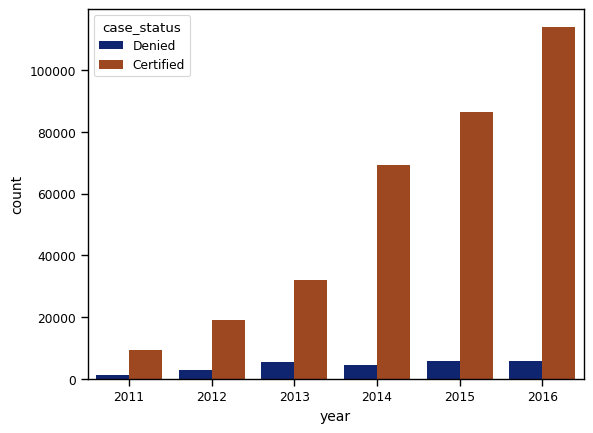

In [240]:
#Year Wise Status

sns.countplot(x = 'year', hue = 'case_status', data = df, palette = 'dark')

In [241]:
# Insights >> Upward trend for certified >> 2016 is highest

In [242]:
df.employer_city.unique()

array(['NEW YORK', 'CARLSTADT', 'GLEN ALLEN', ..., 'austin',
       'Carson City', 'Northfield'], dtype=object)

In [243]:
df.employer_city.value_counts()

,count
employer_city,
NEW YORK,15992
COLLEGE STATION,11983
SANTA CLARA,10446
SAN JOSE,9004
REDMOND,8469
...,...
NEW SMYRNA BEACH,1
ny,1
Wauwatosa,1


In [244]:
df['employer_city'] = df['employer_city'].str.upper()

In [245]:
df['employer_city'].unique()

array(['NEW YORK', 'CARLSTADT', 'GLEN ALLEN', ..., 'PERRYSVILLE',
       'STILWELL', 'ROYAL OAKS'], dtype=object)

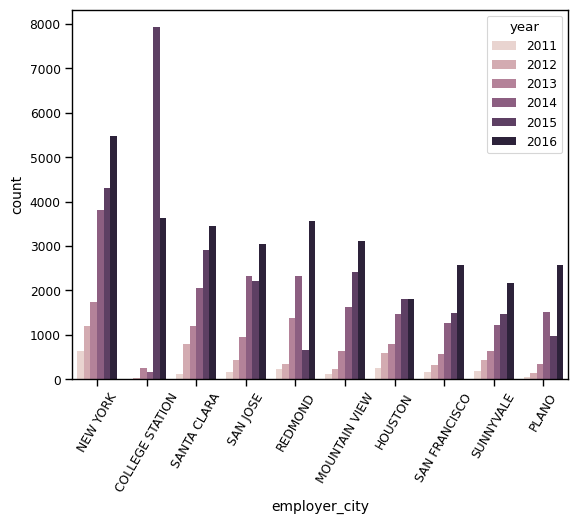

In [246]:
# Employer city year wise: year wise which are the city where the visa approvoved people are worrking
sns.countplot(x = 'employer_city', hue = 'year', data = df, order = df['employer_city'].value_counts().iloc[:10].index)
plt.xticks(rotation = 60)
plt.show()

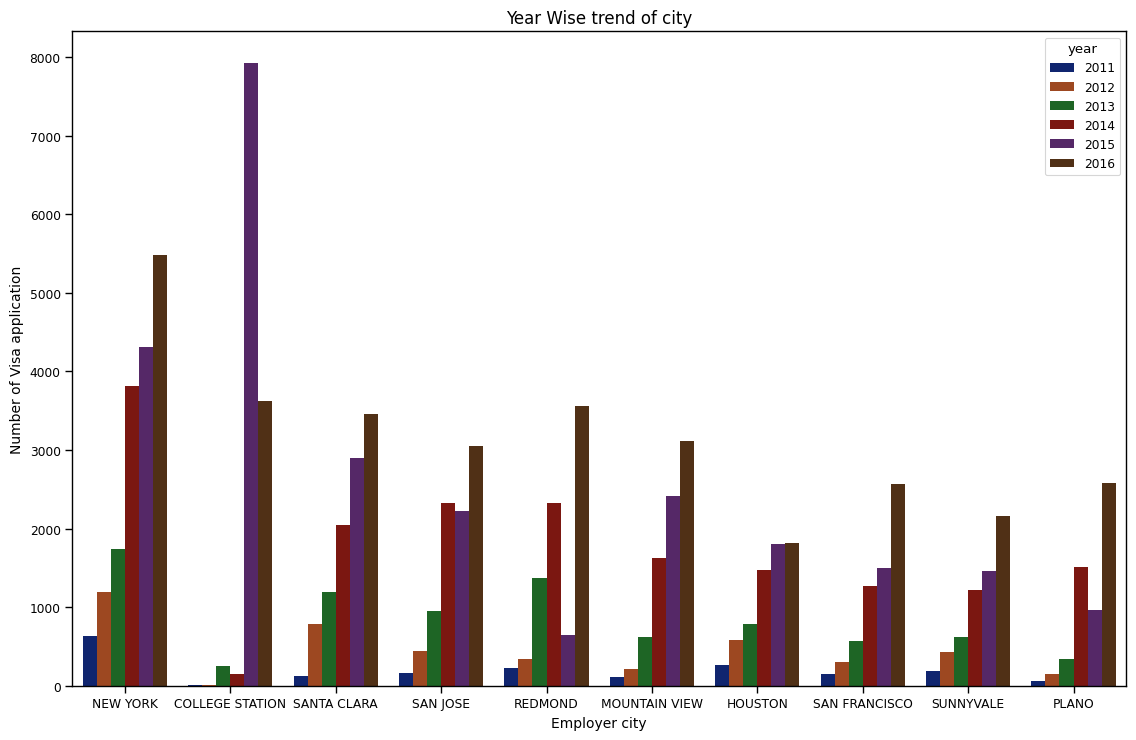

In [247]:
fig, ax = plt.subplots()
fig.set_size_inches(13.6, 8.5)

sns.set_context("paper", rc = {"font.size":12, "axes.titlesize":12, "axes.labelsize":12})
sns.countplot(x = 'employer_city', hue = 'year', data = df, order = df['employer_city'].value_counts().iloc[:10].index, palette = 'dark')
ax.set(xlabel = 'Employer city', ylabel = 'Number of Visa application')
plt.title('Year Wise trend of city')
plt.show()

In [248]:
# Insights >> college station in year 2015 is highest

In [249]:
# Top 10 employees by visa application

In [250]:
top_emp = df['employer_name'].value_counts().head(10)

<Axes: xlabel='employer_name'>

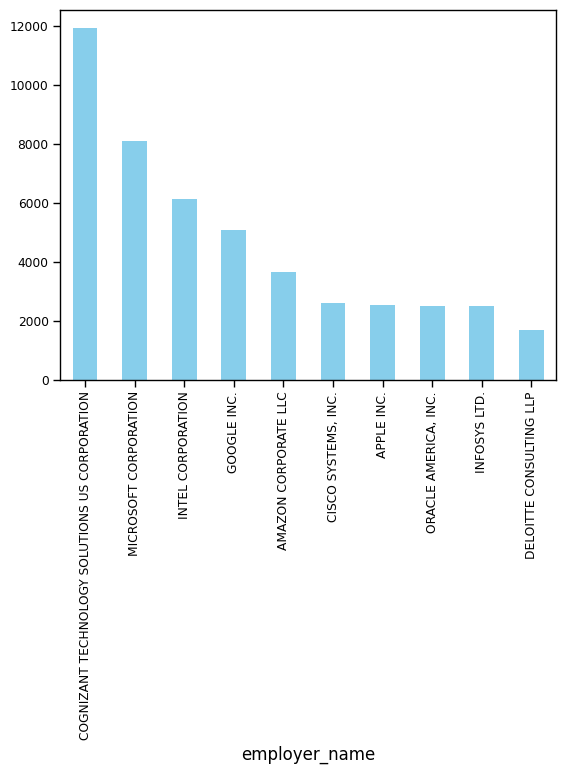

In [251]:
top_emp.plot(kind = 'bar', color = 'skyblue')

In [252]:
for i, v in enumerate(top_emp):
  print(f"{i}: {v}")

0: 11936
1: 8082
2: 6120
3: 5060
4: 3639
5: 2592
6: 2536
7: 2505
8: 2498
9: 1689


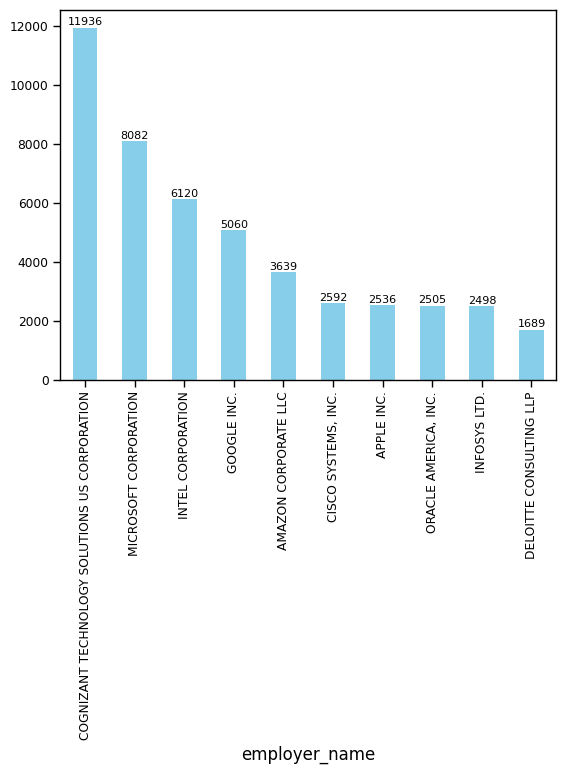

In [253]:
top_emp.plot(kind = 'bar', color = 'skyblue')
for i, v in enumerate(top_emp):
  plt.text(i, v+10, str(v), ha= 'center', va = 'bottom', fontsize = 8)

In [254]:
# Insights >> Highest employee is from Cognizant techonology solutions US Corporation

In [255]:
df['us_economic_sector']

,us_economic_sector
0,IT
1,Other Economic Sector
2,Aerospace
3,Other Economic Sector
4,Advanced Mfg
...,...
374349,NaN
374350,NaN
374351,NaN
374352,NaN


In [256]:
# Value count function from scratch

us_economic_counts = {}
for value in df['us_economic_sector'].dropna():
  if value in us_economic_counts:
    us_economic_counts[value] += 1
  else:
    us_economic_counts[value] = 1

In [257]:
us_economic_counts

{'IT': 49311,
 'Other Economic Sector': 14662,
 'Aerospace': 3917,
 'Advanced Mfg': 17601,
 'Educational Services': 8561,
 'Retail': 4208,
 'Construction': 1315,
 'Hospitality': 1767,
 'Automotive': 1084,
 'Health Care': 6407,
 'Agribusiness': 784,
 'Finance': 8686,
 'Energy': 1021,
 'Transportation': 893,
 'Homeland Security': 78,
 'Biotechnology': 436,
 'Geospatial': 137}

In [258]:
# Nos as key and names of sector as list

In [259]:
uscollabels = []
uscolvalues = []

for key, value in us_economic_counts.items():
  uscollabels.append(key)
  uscolvalues.append(value)

In [260]:
uscollabels

['IT',
 'Other Economic Sector',
 'Aerospace',
 'Advanced Mfg',
 'Educational Services',
 'Retail',
 'Construction',
 'Hospitality',
 'Automotive',
 'Health Care',
 'Agribusiness',
 'Finance',
 'Energy',
 'Transportation',
 'Homeland Security',
 'Biotechnology',
 'Geospatial']

In [261]:
uscolvalues

[49311,
 14662,
 3917,
 17601,
 8561,
 4208,
 1315,
 1767,
 1084,
 6407,
 784,
 8686,
 1021,
 893,
 78,
 436,
 137]

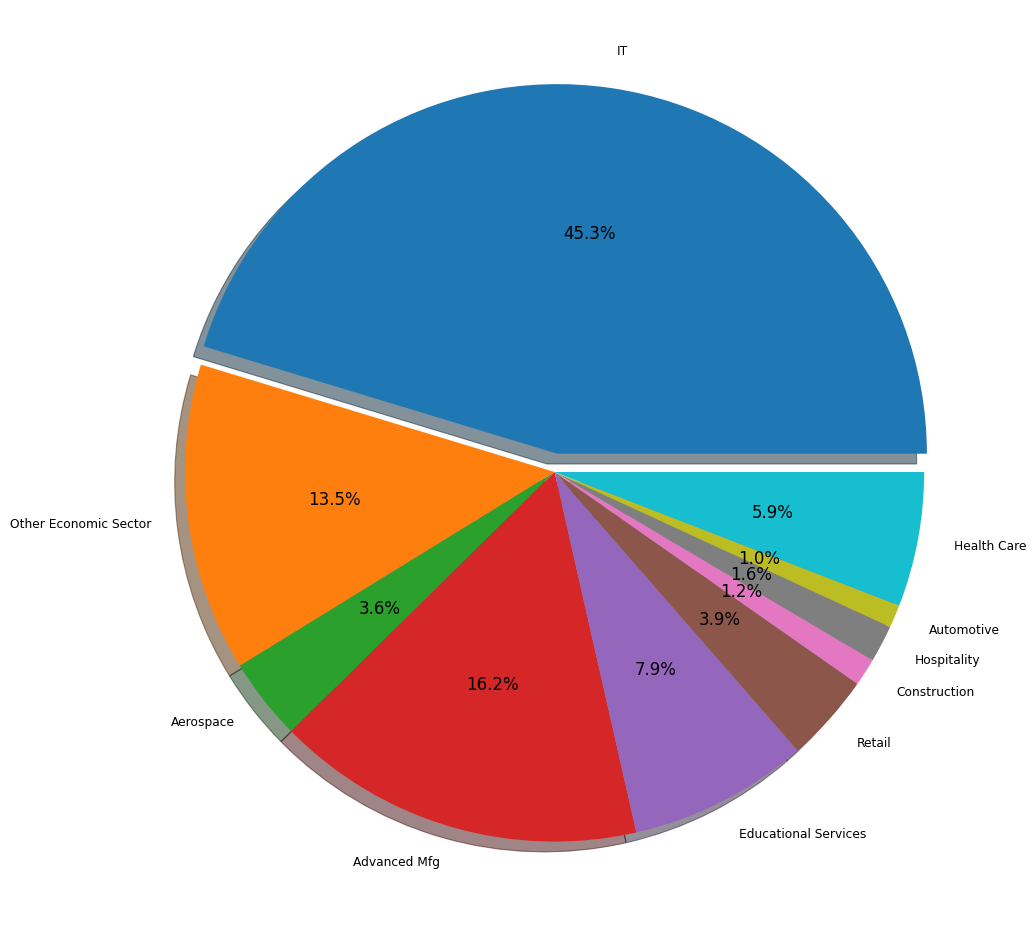

In [262]:
plt.figure(figsize = (12,12))
plt.pie(uscolvalues[:10], labels = uscollabels[:10], autopct = "%1.1f%%", explode = [0.05, 0,0,0,0,0,0,0,0,0], shadow=True)
plt.show()

In [263]:
# Insights >> IT sector is leading US Economic sector with 45.3%

In [264]:
df.columns

Index(['add_these_pw_job_title_9089', 'agent_city', 'agent_firm_name',
       'agent_state', 'application_type', 'case_received_date', 'case_status',
       'class_of_admission', 'country_of_citizenship', 'country_of_citzenship',
       ...
       'wage_offer_from_9089', 'wage_offer_to_9089',
       'wage_offer_unit_of_pay_9089', 'wage_offered_from_9089',
       'wage_offered_to_9089', 'wage_offered_unit_of_pay_9089', 'casenumber',
       'year', 'month', 'day'],
      dtype='object', length=155)

In [265]:
df['job_info_job_title']

,job_info_job_title
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
374349,Senior .NET Developer(s)
374350,Software Engineer
374351,Computer Systems Architect
374352,"Assistant Vice President, Divisional Business ..."


In [266]:
df['job_info_job_title'].value_counts()[:20]

,count
job_info_job_title,
Software Engineer,14372
Computer Systems Analyst - V,4747
Senior Software Engineer,3801
Computer Systems Analyst - II,3416
Software Developer,2880
Assistant Professor,2604
Programmer Analyst,2534
Computer Systems Analyst - IV,2496
Systems Analyst,2034


In [267]:
# Computer Systems Analyst - V , Computer Systems Analyst - IV and so on, have different job title
# but job profile/domain is same

# software engineer , SOFTWARE ENGINEER, Sr. Software Engineer >> all of this should come in same profile

In [268]:
df.job_info_job_title = df.job_info_job_title.str.lower()
#Splitting job titles by '-'
df['job_info_job_title'] = df['job_info_job_title'].astype(str).str.split('-').str[0]
#Splitting job titles by 'ii'
df['job_info_job_title'] = df['job_info_job_title'].astype(str).str.split('ii').str[0]
#Splitting job titles by '/'
df['job_info_job_title'] = df['job_info_job_title'].astype(str).str.split('/').str[0]
#Removing leading and ending spaces
df['job_info_job_title'] = df['job_info_job_title'].astype(str).str.strip()
#Replacing "sr." values with "senior"
df['job_info_job_title'] = df['job_info_job_title'].str.replace('sr.', 'senior')
#Replacing "NaN", "NaT" and "nan" values with np.nan
df['job_info_job_title'].replace(["NaN", 'NaT','nan'], np.nan, inplace = True)

df['job_info_job_title'].value_counts(dropna=True)[:10]

,count
job_info_job_title,
software engineer,18582
computer systems analyst,12054
senior software engineer,5802
software developer,4501
programmer analyst,3763
assistant professor,2869
software development engineer,2766
systems analyst,2587
senior programmer analyst,1884


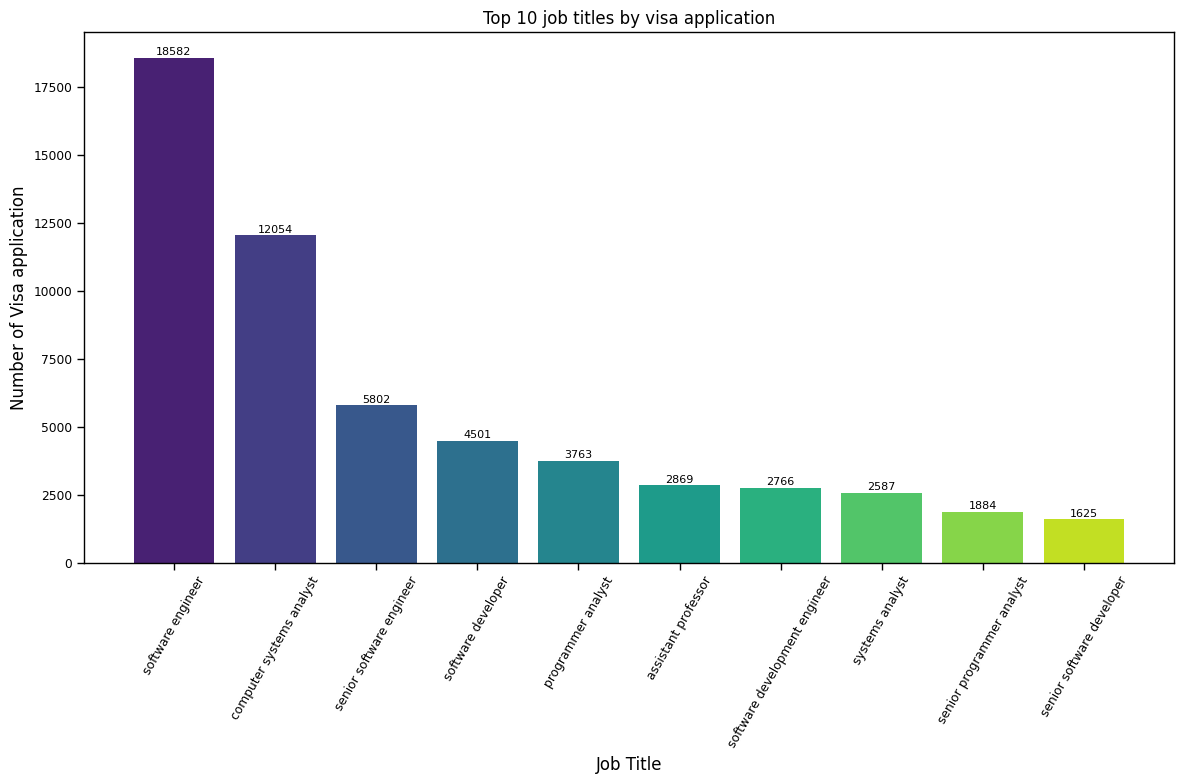

In [269]:
# Get the top 10 job titles by count

top_job_titles = df.job_info_job_title.value_counts().head(10)

# Create a bar plot
plt.figure(figsize = (12,8))
plt.bar(top_job_titles.index, top_job_titles, color = sns.color_palette("viridis", len(top_job_titles)))

# Add count labels above the bars
for i, v in enumerate(top_job_titles):
  plt.text(i, v+10, str(v), ha = 'center', va = 'bottom', fontsize = 8)   # rotation = 90

plt.xlabel('Job Title')
plt.ylabel('Number of Visa application')
plt.title('Top 10 job titles by visa application')
plt.xticks(rotation = 60)
plt.tight_layout()
plt.show()

In [270]:
# Insights >> Software Engineers applies most for visa appliocation

In [271]:
df.columns

Index(['add_these_pw_job_title_9089', 'agent_city', 'agent_firm_name',
       'agent_state', 'application_type', 'case_received_date', 'case_status',
       'class_of_admission', 'country_of_citizenship', 'country_of_citzenship',
       ...
       'wage_offer_from_9089', 'wage_offer_to_9089',
       'wage_offer_unit_of_pay_9089', 'wage_offered_from_9089',
       'wage_offered_to_9089', 'wage_offered_unit_of_pay_9089', 'casenumber',
       'year', 'month', 'day'],
      dtype='object', length=155)

In [272]:
# Convert column country_of_citizenship to categorical data type

df.country_of_citizenship = pd.Categorical(df.country_of_citizenship)

In [273]:
df.country_of_citizenship

,country_of_citizenship
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
374349,INDIA
374350,INDIA
374351,INDIA
374352,INDIA


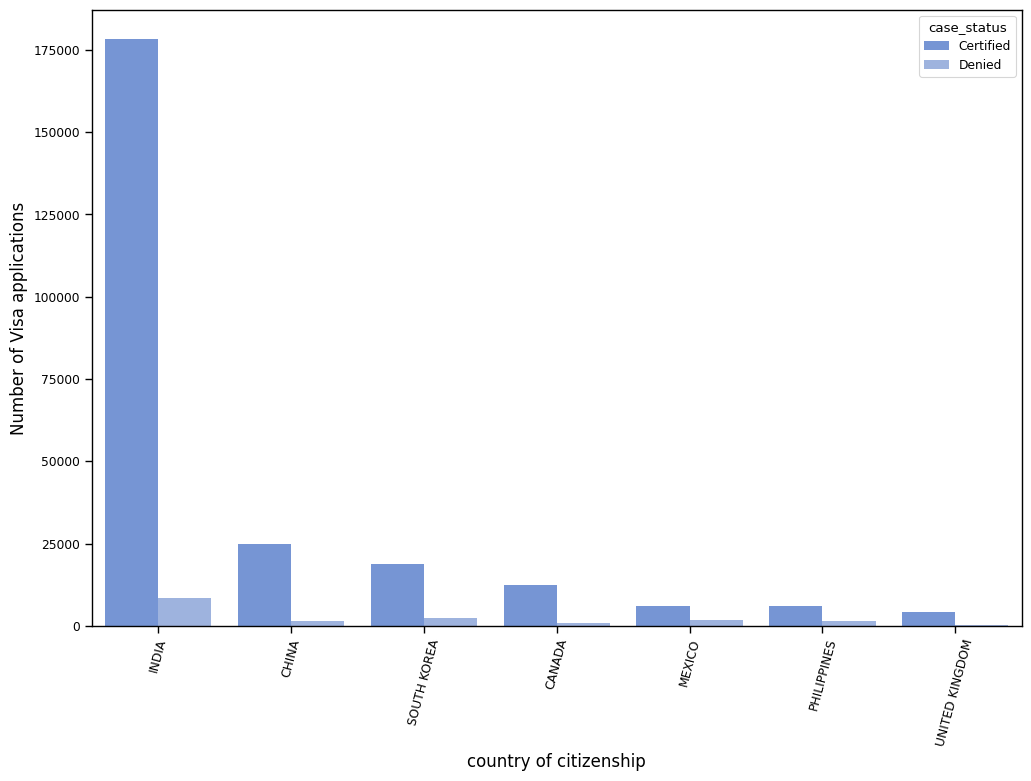

In [274]:
fig, ax = plt.subplots(figsize = (12,8))
sns.set_context(rc = {"font.size":12, "axes.labelsize":10})

# Creating the count plot
sns.countplot(x = 'country_of_citizenship', hue = 'case_status', data = df,
              palette = sns.diverging_palette(255,133,l=60, n=7, center= "light"),
              order = df.country_of_citizenship.value_counts().iloc[:7].index)

plt.xticks(rotation = 75)

# Setting label titles
ax.set(xlabel = 'country of citizenship', ylabel = 'Number of Visa applications')

plt.show()    # This line is necessary to display the plot

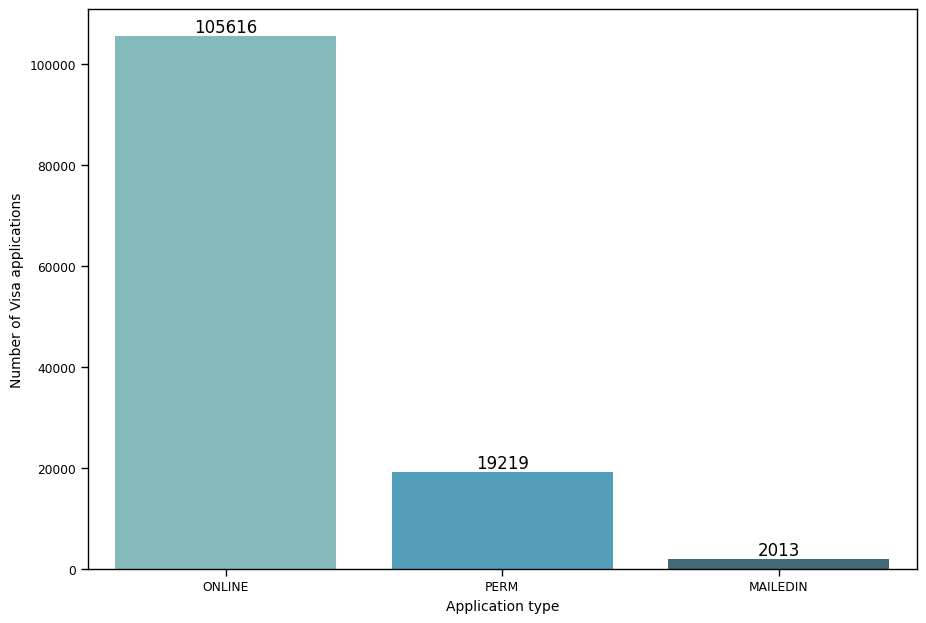

In [275]:
plt.figure(figsize=(10.7, 7.27))
sns.countplot(x='application_type', data=df, palette='GnBu_d', order=df['application_type'].value_counts().index[:10])

# Iterating over elements in "application_type" column and displaying counts above bars
for i, v in enumerate(df['application_type'].value_counts().head(10)):
  plt.text(i,v, str(v), ha = 'center', va = 'bottom')

# Setting labels
plt.xlabel('Application type')
plt.ylabel('Number of Visa applications')
plt.show()

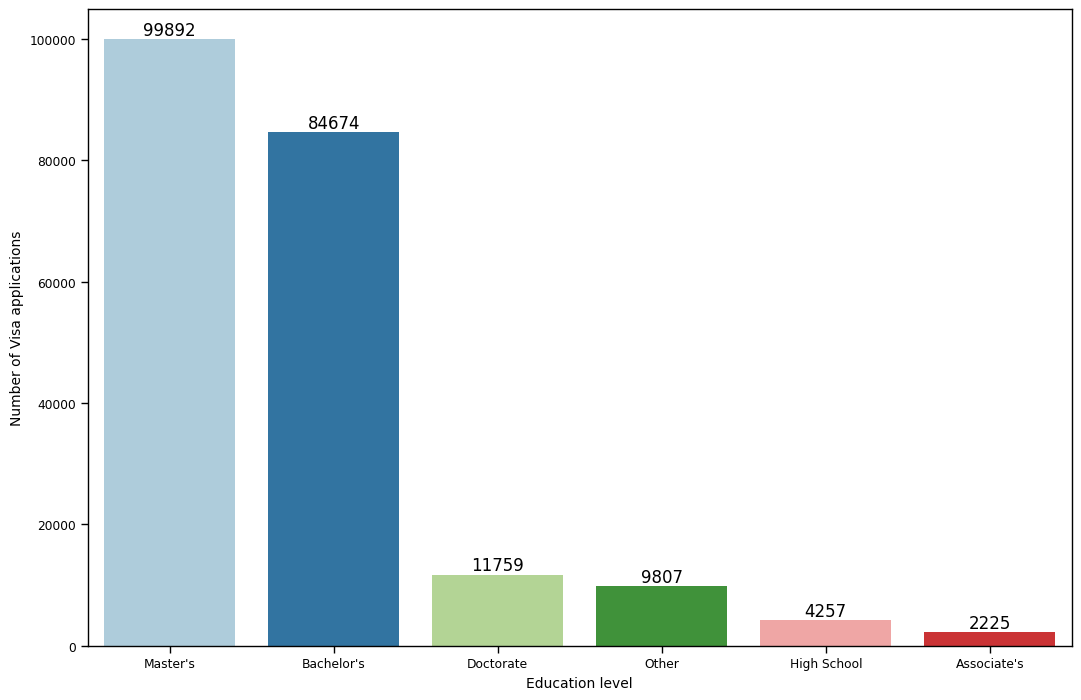

In [276]:
# Setting plot parameters
fig, ax = plt.subplots()
fig.set_size_inches(12.7, 8.27)
# sns.set_context(rc = {"font.size":12, "axes.labelsize":10})

sns.countplot(x='foreign_worker_info_education', data=df, palette=sns.color_palette("Paired"), order=df['foreign_worker_info_education'].value_counts().index[:10])

# Iterating over elements in "foreign_worker_info_education" column and displaying counts above bars
for i,v in enumerate(df['foreign_worker_info_education'].value_counts().head(10)):
  ax.text(i,v, str(v), ha = 'center', va = 'bottom')

ax.set(xlabel='Education level', ylabel='Number of Visa applications')
plt.show()

In [277]:
#percentage of non null values

i = 0;
for col in df.columns:
    i = i+1;
    print (i-1,"Column: '{}'".format(col),"contains ", np.round(100*df[col].count()/len(df['case_status']),decimals=2),"% non-null values" )

0 Column: 'add_these_pw_job_title_9089' contains  10.99 % non-null values
1 Column: 'agent_city' contains  56.92 % non-null values
2 Column: 'agent_firm_name' contains  55.74 % non-null values
3 Column: 'agent_state' contains  56.05 % non-null values
4 Column: 'application_type' contains  35.61 % non-null values
5 Column: 'case_received_date' contains  64.39 % non-null values
6 Column: 'case_status' contains  100.0 % non-null values
7 Column: 'class_of_admission' contains  94.08 % non-null values
8 Column: 'country_of_citizenship' contains  94.59 % non-null values
9 Column: 'country_of_citzenship' contains  5.4 % non-null values
10 Column: 'employer_address_1' contains  99.99 % non-null values
11 Column: 'employer_address_2' contains  33.7 % non-null values
12 Column: 'employer_city' contains  100.0 % non-null values
13 Column: 'employer_country' contains  64.37 % non-null values
14 Column: 'employer_decl_info_title' contains  64.37 % non-null values
15 Column: 'employer_name' contains

In [278]:
# Keep the columns with non null values count > 330000

df = df.loc[:, df.count() >= 330000]

In [279]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356168 entries, 0 to 374353
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   case_status             356168 non-null  object  
 1   class_of_admission      335083 non-null  object  
 2   country_of_citizenship  336896 non-null  category
 3   employer_address_1      356131 non-null  object  
 4   employer_city           356158 non-null  object  
 5   employer_name           356160 non-null  object  
 6   employer_postal_code    356135 non-null  object  
 7   employer_state          356131 non-null  object  
 8   job_info_work_city      356073 non-null  object  
 9   job_info_work_state     356072 non-null  object  
 10  pw_amount_9089          353965 non-null  object  
 11  pw_soc_code             355594 non-null  object  
 12  pw_soc_title            353847 non-null  object  
 13  pw_source_name_9089     354081 non-null  object  
 14  pw_unit_o

In [280]:
df.case_status

,case_status
0,Certified
1,Denied
2,Certified
3,Certified
4,Certified
...,...
374349,Certified
374350,Certified
374351,Certified
374352,Certified


In [281]:
df.loc[df["case_status"] == 'Certified', 'case_status'] = 1
df.loc[df["case_status"] == 'Denied', 'case_status'] = 0

In [282]:
df['case_status'].unique()

array([1, 0], dtype=object)

In [283]:
df['employer_state'].isnull().sum()

np.int64(37)

In [284]:
df['employer_state'].mode()[0]

'CALIFORNIA'

In [285]:
df['employer_state'] = df['employer_state'].fillna(df['employer_state'].mode()[0])

In [286]:
df['employer_state'].isnull().sum()

np.int64(0)

In [287]:
df['employer_state'].unique()

array(['NY', 'VA', 'FL', 'DE', 'NJ', 'GA', 'MD', 'IL', 'TX', 'KY', 'WY',
       'OH', 'MS', 'MA', 'NC', 'CA', 'MO', 'CT', 'AZ', 'WI', 'PA', 'WA',
       'CO', 'MN', 'NV', 'UT', 'AL', 'OK', 'LA', 'RI', 'DC', 'MI', 'IA',
       'NH', 'IN', 'SD', 'CALIFORNIA', 'OR', 'NE', 'KS', 'TN', 'PR', 'AR',
       'GU', 'WV', 'SC', 'ID', 'VI', 'ND', 'HI', 'VT', 'ME', 'NM', 'MP',
       'AK', 'MT', 'GEORGIA', 'NEW YORK', 'TEXAS', 'WASHINGTON',
       'NEW JERSEY', 'ARIZONA', 'NORTH CAROLINA', 'WISCONSIN',
       'LOUISIANA', 'MAINE', 'OHIO', 'MARYLAND', 'MASSACHUSETTS',
       'MICHIGAN', 'ILLINOIS', 'PENNSYLVANIA', 'VERMONT', 'VIRGINIA',
       'FLORIDA', 'MISSOURI', 'ARKANSAS', 'NEW HAMPSHIRE', 'INDIANA',
       'OKLAHOMA', 'UTAH', 'CONNECTICUT', 'SOUTH DAKOTA', 'DELAWARE',
       'ALABAMA', 'WEST VIRGINIA', 'NEBRASKA', 'OREGON', 'COLORADO',
       'RHODE ISLAND', 'KANSAS', 'ALASKA', 'DISTRICT OF COLUMBIA',
       'MINNESOTA', 'TENNESSEE', 'KENTUCKY', 'GUAM', 'IOWA', 'NEW MEXICO',
       'NORTH DAKO

In [289]:
# Dictionary for mapping state names to abbreviations
state_abbrevs = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
    'Northern Mariana Islands':'MP',
    'Palau': 'PW',
    'Puerto Rico': 'PR',
    'Virgin Islands': 'VI',
    'District of Columbia': 'DC'
}

In [290]:
# Reverse dictionary for abbreviation to state name mapping
abbrev_to_state = {v: k.upper() for k, v in state_abbrevs.items()}

# Clean and transform employer_state column in DataFrame
df['employer_state'] = df['employer_state'].fillna('').astype(str).str.strip().str.upper()

# Replace abbreviations with full state names
df['employer_state'] = df['employer_state'].replace(abbrev_to_state)

In [291]:
df['employer_state']

,employer_state
0,NEW YORK
1,NEW YORK
2,VIRGINIA
3,NEW YORK
4,NEW YORK
...,...
374349,KENTUCKY
374350,OHIO
374351,CALIFORNIA
374352,NEW YORK


In [293]:
df.pw_soc_code

,pw_soc_code
0,15-1031.00
1,47-4041.00
2,17-2051.00
3,43-4071.00
4,41-9031.00
...,...
374349,15-1132
374350,15-1132
374351,15-1121
374352,15-1122


In [294]:
df.pw_soc_code.unique()

array(['15-1031.00', '47-4041.00', '17-2051.00', ..., '47-2031.03',
       '51-5022.00', '41-9091'], dtype=object)

In [295]:
df['pw_soc_code'] = df['pw_soc_code'].str.replace('.','')
df['pw_soc_code'] = df['pw_soc_code'].str.replace('-','')
df['pw_soc_code'] = df['pw_soc_code'].astype(str).str[0:6]
df['pw_soc_code'].value_counts()

,count
pw_soc_code,
151132,110421
151121,32618
151133,20493
172072,12566
113021,7531
...,...
493022,1
454023,1
272023,1


In [296]:
# Finding 'None', 'nan', and replacing them with mode

df.loc[df['pw_soc_code'] == "nan", "pw_soc_code"] = df['pw_soc_code'].mode()[0]
df.loc[df['pw_soc_code'] == "None", "pw_soc_code"] = df['pw_soc_code'].mode()[0]

# Changing type from string to int
df['pw_soc_code'] = df['pw_soc_code'].astype(int)
df['case_status'] = df['case_status'].astype(int)

In [298]:
df['case_status']

,case_status
0,1
1,0
2,1
3,1
4,1
...,...
374349,1
374350,1
374351,1
374352,1


In [299]:
df['class_of_admission'].unique()

array(['J-1', 'B-2', 'H-1B', 'L-1', 'EWI', 'E-2', nan, 'E-1', 'H-2B',
       'TPS', 'F-1', 'B-1', 'C-1', 'Not in USA', 'TN', 'H-4', 'O-1',
       'R-1', 'L-2', 'Q', 'F-2', 'H-1B1', 'Parolee', 'G-5', 'E-3', 'H-2A',
       'VWT', 'P-1', 'A1/A2', 'D-1', 'A-3', 'R-2', 'H-1C', 'H-3', 'J-2',
       'P-4', 'I', 'H-1A', 'G-1', 'VWB', 'G-4', 'P-3', 'AOS/H-1B', 'O-3',
       'Parol', 'O-2', 'H1B', 'N', 'T-1', 'TD', 'M-1', 'U-1', 'AOS',
       'P-2', 'C-3', 'K-1', 'V-2', 'M-2'], dtype=object)

In [300]:
df['class_of_admission'] = df['class_of_admission'].fillna(df['class_of_admission'].mode()[0])

In [302]:
df['class_of_admission']

,class_of_admission
0,J-1
1,B-2
2,H-1B
3,B-2
4,L-1
...,...
374349,H-1B
374350,H-1B
374351,L-1
374352,H-1B


In [303]:
# Missing value treatment for other columns
# Replacing missing values with mode in categorical columns

df['class_of_admission'] = df['class_of_admission'].fillna(df['class_of_admission'].mode()[0])
df['country_of_citizenship'] = df['country_of_citizenship'].fillna(df['country_of_citizenship'].mode()[0])
df['employer_city'] = df['employer_city'].fillna(df['employer_city'].mode()[0])
df['employer_name'] = df['employer_name'].fillna(df['employer_name'].mode()[0])
df['pw_source_name_9089'] = df['pw_source_name_9089'].fillna(df['pw_source_name_9089'].mode()[0])
df['employer_name'] = df['employer_name'].astype(str).str.upper()

In [304]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356168 entries, 0 to 374353
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   case_status             356168 non-null  int64   
 1   class_of_admission      356168 non-null  object  
 2   country_of_citizenship  356168 non-null  category
 3   employer_address_1      356131 non-null  object  
 4   employer_city           356168 non-null  object  
 5   employer_name           356168 non-null  object  
 6   employer_postal_code    356135 non-null  object  
 7   employer_state          356168 non-null  object  
 8   job_info_work_city      356073 non-null  object  
 9   job_info_work_state     356072 non-null  object  
 10  pw_amount_9089          353965 non-null  object  
 11  pw_soc_code             356168 non-null  int64   
 12  pw_soc_title            353847 non-null  object  
 13  pw_source_name_9089     356168 non-null  object  
 14  pw_unit_o

In [305]:
# Convert the column containing numerical values with commas to numeric format
df['pw_amount_9089'] = df['pw_amount_9089'].str.replace(',','').astype(float)

# Now, replace null values in the numerical column with the median
median_pw_amount = df['pw_amount_9089'].median()
df['pw_amount_9089'].fillna(median_pw_amount, inplace = True)

In [306]:
# Verify that there are no more null values
print(df.isnull().sum())

case_status                  0
class_of_admission           0
country_of_citizenship       0
employer_address_1          37
employer_city                0
employer_name                0
employer_postal_code        33
employer_state               0
job_info_work_city          95
job_info_work_state         96
pw_amount_9089               0
pw_soc_code                  0
pw_soc_title              2321
pw_source_name_9089          0
pw_unit_of_pay_9089       1481
casenumber                   0
year                         0
month                        0
day                          0
dtype: int64


In [307]:
#Indices of selected features for categorcal data to do encoding
chosen_attrs = [0,1,2,5,6,8,12,14,17]
df = df.iloc[:,chosen_attrs]

In [313]:
from sklearn.preprocessing import LabelEncoder
categorical_variables = {}

# Creating categories denoted by integers from column values
for col in df.columns:
    # Convert object and category columns to string type to handle mixed types and NaNs
    if df[col].dtype == 'object' or df[col].dtype == 'category':
        df[col] = df[col].astype(str)

    cat_var_name = "cat_"+ col
    cat_var_name = LabelEncoder()
    cat_var_name.fit(df[col])
    df[col] = cat_var_name.transform(df[col])
    categorical_variables[col] = cat_var_name

In [314]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356168 entries, 0 to 374353
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   case_status             356168 non-null  int64
 1   class_of_admission      356168 non-null  int64
 2   country_of_citizenship  356168 non-null  int64
 3   employer_name           356168 non-null  int64
 4   employer_postal_code    356168 non-null  int64
 5   job_info_work_city      356168 non-null  int64
 6   pw_soc_title            356168 non-null  int64
 7   pw_unit_of_pay_9089     356168 non-null  int64
 8   month                   356168 non-null  int64
dtypes: int64(9)
memory usage: 27.2 MB


In [315]:
df

,case_status,class_of_admission,country_of_citizenship,employer_name,employer_postal_code,job_info_work_city,pw_soc_title,pw_unit_of_pay_9089,month
0,1,28,79,42973,1213,5636,167,10,1
1,0,5,79,47896,10614,5636,419,10,11
2,1,19,79,54186,3962,4577,124,10,11
3,1,5,79,18698,1729,2750,328,6,11
4,1,31,79,2602,2038,222,748,10,0
...,...,...,...,...,...,...,...,...,...
374349,1,19,79,48352,6968,2828,797,4,11
374350,1,19,79,55538,7398,5121,797,4,11
374351,1,31,79,24596,15112,7381,175,4,11
374352,1,19,79,16913,1199,5448,466,4,11
